In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

In [21]:
matplotlib.rcParams['figure.dpi'] = 150

DB_PATH = Path.cwd().resolve().parent / "data" / "hybrid_esports.db"
conn = sqlite3.connect(str(DB_PATH))

opp    = pd.read_sql("SELECT * FROM fact_opportunity_scores ORDER BY opportunity_score DESC", conn)
games  = pd.read_sql("SELECT * FROM dim_game", conn)
cafes  = pd.read_sql("SELECT * FROM dim_cafe", conn)
stream = pd.read_sql("SELECT * FROM fact_streaming_metrics", conn)
reviews= pd.read_sql("SELECT * FROM fact_review_engagement", conn)
conn.close()

REPORTS = Path.cwd().resolve().parent / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

print("Tables loaded:")
print("Opportunity scores:", len(opp))
print("Games:", len(games))
print("Cafés:", len(cafes))
print("Streaming rows:", len(stream))

Tables loaded:
Opportunity scores: 5
Games: 5
Cafés: 8
Streaming rows: 5


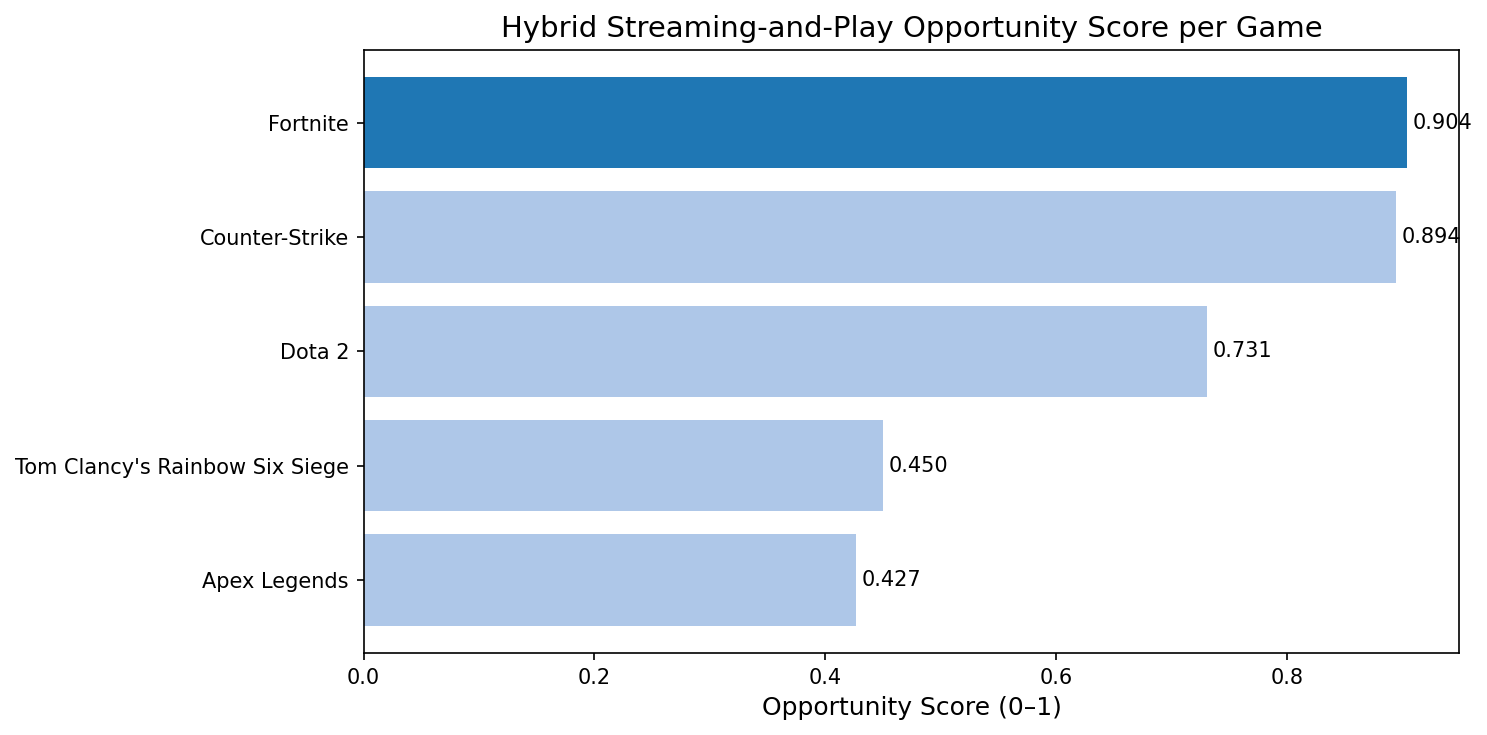

Saved fig1


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1f77b4" if i == 0 else "#aec7e8" for i in range(len(opp))]
ax.barh(opp["title"], opp["opportunity_score"], color=colors)
ax.set_xlabel("Opportunity Score (0–1)", fontsize=12)
ax.set_title("Hybrid Streaming-and-Play Opportunity Score per Game", fontsize=14)
ax.invert_yaxis()
for i, v in enumerate(opp["opportunity_score"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
plt.tight_layout()
plt.savefig(str(REPORTS / "fig1_opportunity_scores.png"), dpi=150)
plt.show()
print("Saved fig1")

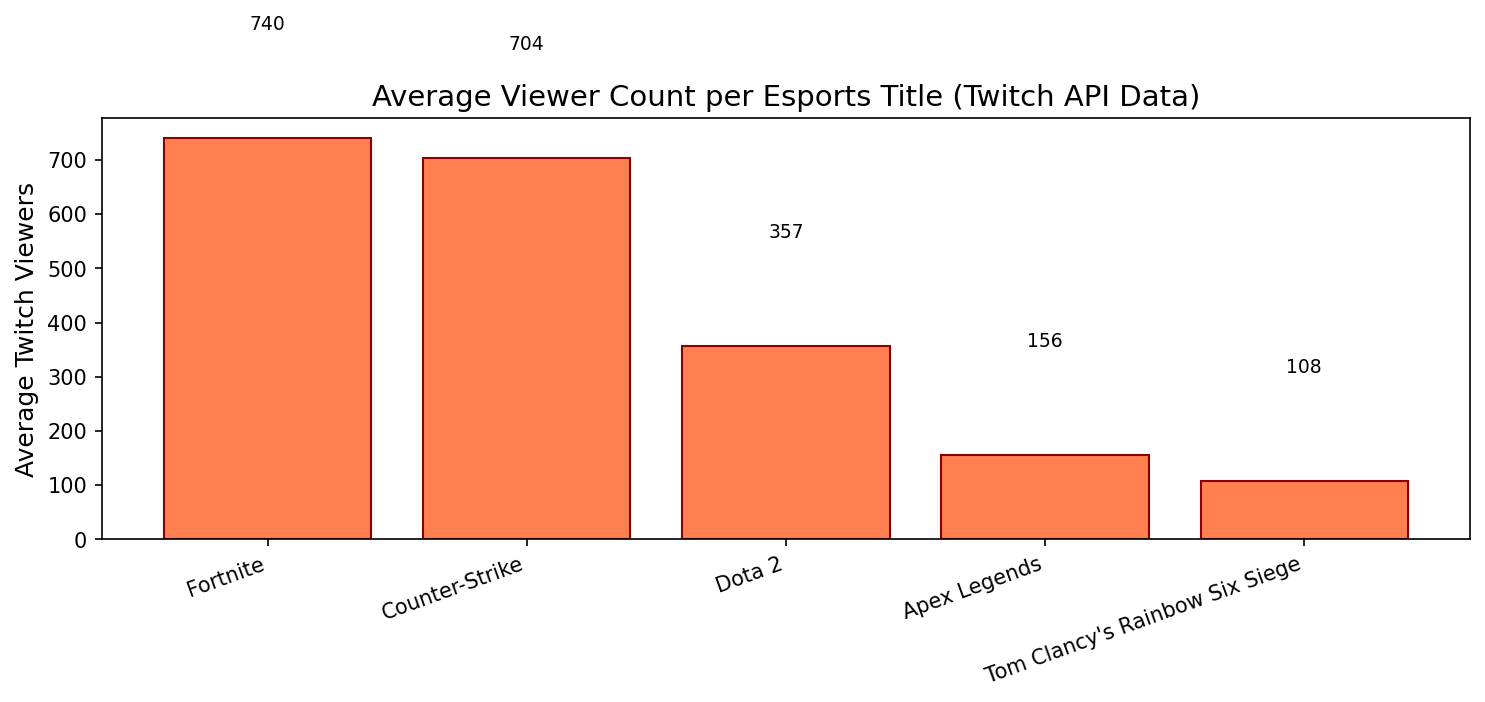

Saved fig2


In [23]:
avg_views = stream.groupby("game_id")["avg_viewers"].mean().reset_index()
avg_views = avg_views.merge(games[["game_id","title"]], on="game_id")
avg_views = avg_views.sort_values("avg_viewers", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_views["title"], avg_views["avg_viewers"], color="coral", edgecolor="darkred")
ax.set_ylabel("Average Twitch Viewers", fontsize=12)
ax.set_title("Average Viewer Count per Esports Title (Twitch API Data)", fontsize=14)
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(avg_views["avg_viewers"]):
    ax.text(i, v + 200, f"{int(v):,}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(REPORTS / "fig2_avg_viewers.png"), dpi=150)
plt.show()
print("Saved fig2")

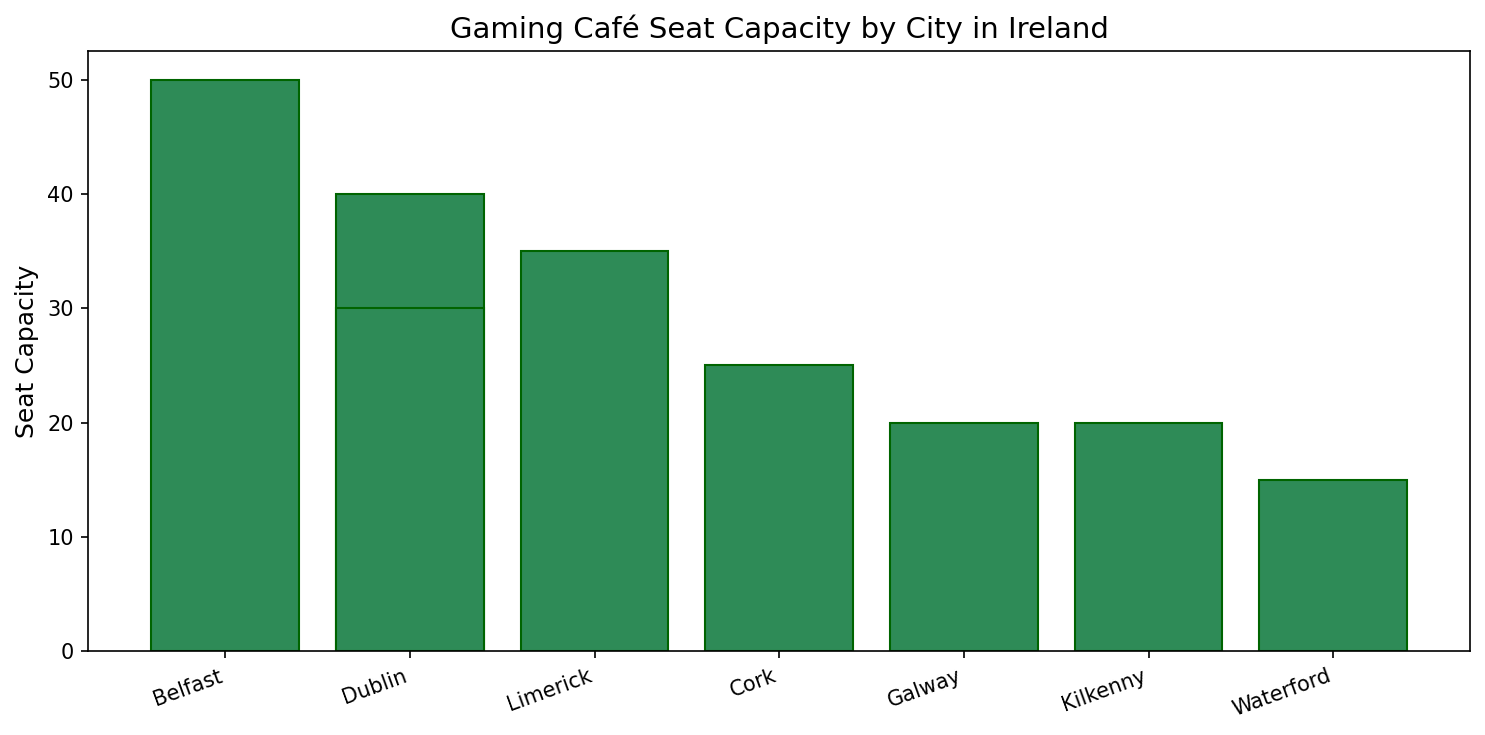

Saved fig3


In [24]:
cafes_sorted = cafes.sort_values("capacity", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cafes_sorted["city"], cafes_sorted["capacity"], color="seagreen", edgecolor="darkgreen")
ax.set_ylabel("Seat Capacity", fontsize=12)
ax.set_title("Gaming Café Seat Capacity by City in Ireland", fontsize=14)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(str(REPORTS / "fig3_cafe_capacity.png"), dpi=150)
plt.show()
print("Saved fig3")

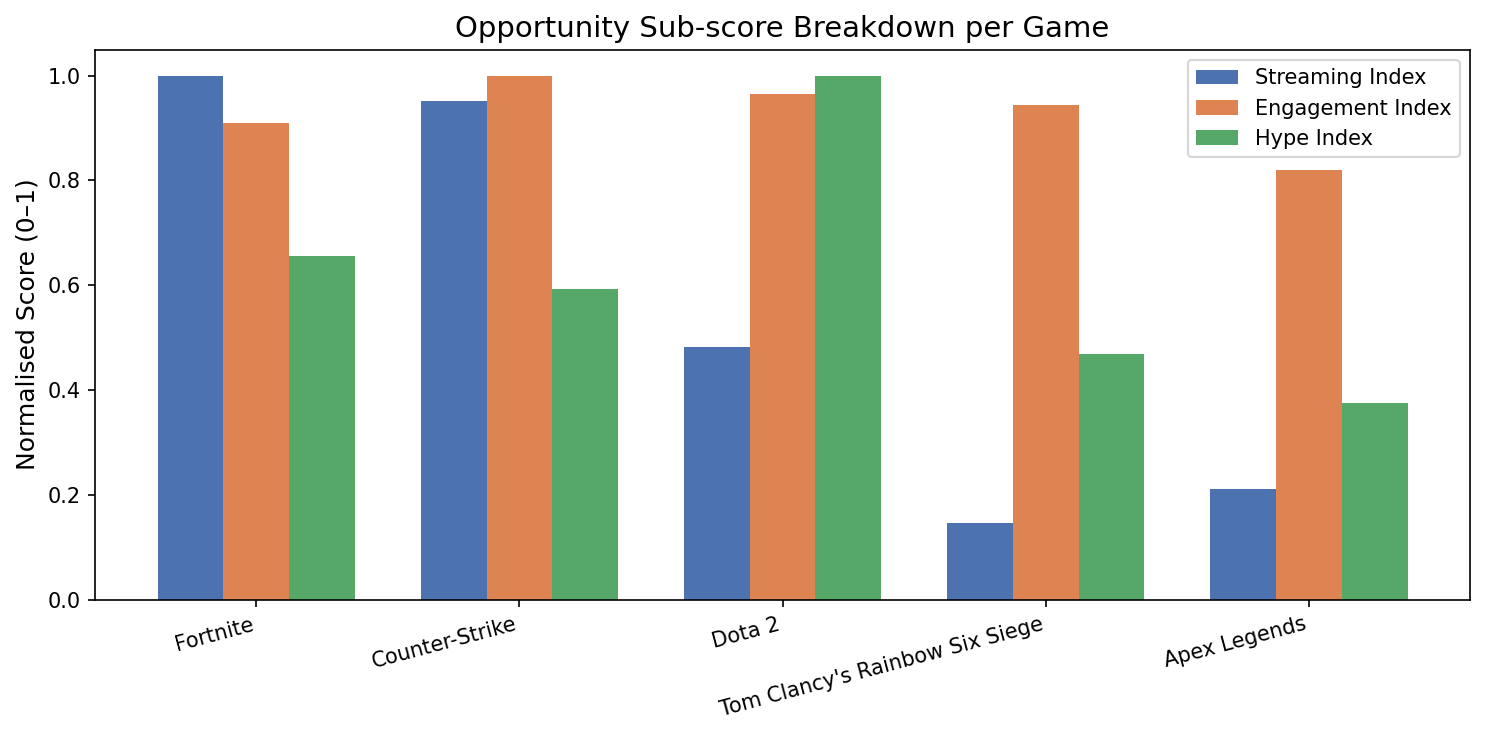

Saved fig4

All charts saved to reports/ folder.


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(opp))
width = 0.25
ax.bar([i - width for i in x], opp["streaming_index"],  width, label="Streaming Index",  color="#4C72B0")
ax.bar([i         for i in x], opp["engagement_index"], width, label="Engagement Index", color="#DD8452")
ax.bar([i + width for i in x], opp["hype_index"],       width, label="Hype Index",       color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(opp["title"], rotation=15, ha="right")
ax.set_ylabel("Normalised Score (0–1)", fontsize=12)
ax.set_title("Opportunity Sub-score Breakdown per Game", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(str(REPORTS / "fig4_subscore_breakdown.png"), dpi=150)
plt.show()
print("Saved fig4")
print("\nAll charts saved to reports/ folder.")